# Question 1 — Goals

Is the average number of goals per match significantly different between the Group Stage and Knockout Stage of the FIFA World Cup 2026?

**Objective 1.** Run the cells from top to bottom. This notebook loads the original CSV independently. Tables and graphs appear directly beneath their code cells.

## 1. Libraries and project paths
Use the project `.venv` kernel. Inline plotting keeps the figures inside this notebook.

In [17]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

QUESTION = 'Is the average number of goals per match significantly different between the Group Stage and Knockout Stage of the FIFA World Cup 2026?'
NUMBER = 1
ROOT = Path.cwd()
if not (ROOT / 'data').is_dir():
    ROOT = ROOT.parent
BASE = ROOT / 'Question_1_Goals'
for directory in ['processed_data', 'figures', 'tables', 'results']:
    (BASE / directory).mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 35)
print(QUESTION)

Is the average number of goals per match significantly different between the Group Stage and Knockout Stage of the FIFA World Cup 2026?


## 2. Load and inspect the raw CSV
The file has 28 columns and repeated stage/header rows. We inspect these before selecting match observations.

In [18]:
path = ROOT / 'data' / 'World Cup - 2026 - Stats - Fixtures.csv'
raw = pd.read_csv(path, header=None)
headers = pd.read_csv(path, header=2, nrows=0).columns.tolist()
print('Raw rows:', len(raw), '| Columns:', raw.shape[1])
display(raw.head())

Raw rows: 121 | Columns: 28


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,GROUP STAGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,GOALS,NaN,NaN,NaN,CARDS,NaN,NaN,NaN,CORNERS,NaN,NaN,NaN,NaN,NaN,NaN,xG,NaN,SHOTS,NaN,SHOTS ON\nTARGET,NaN,FOULS,NaN
2,Date,Team 1,Result,NaN,Team 2,1H,NaN,2H,NaN,YEL,NaN,RED,NaN,1H C,NaN,2H C,NaN,MC,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11/6/2026,Mexico,2,0,South Africa,1,0.0,1,0.0,1,2.0,1,2.0,2,1.0,1,0.0,3,1.0,4,1.46,0.07,16,3.0,4,2.0,12,11.0
4,12/6/2026,South Korea,2,1,Czech Republic,0,0.0,2,1.0,1,0.0,0,0.0,3,3.0,1,2.0,4,5.0,9,2.3,0.83,15,7.0,6,4.0,9,16.0


In [4]:
column_inspection = pd.DataFrame({
    'Position': range(raw.shape[1]),
    'Original pandas name (header=2)': headers,
    'Raw data type': raw.dtypes.astype(str).values,
    'Missing values': raw.isnull().sum().values
})
display(column_inspection)
print('Raw duplicate records (including repeated headers):', raw.duplicated().sum())

,Position,Original pandas name (header=2),Raw data type,Missing values
0,0,Date,str,6
1,1,Team 1,str,12
2,2,Result,str,12
3,3,Unnamed: 3,str,18
4,4,Team 2,str,12
5,5,1H,str,6
6,6,Unnamed: 6,float64,18
7,7,2H,str,12
8,8,Unnamed: 8,float64,18
9,9,YEL,str,6


Raw duplicate records (including repeated headers): 9


## 3. Extract match rows and identify stages
Stage labels are section headings. Carry them down to their matches and remove the repeated headers. No merge is required.

In [19]:
stages = ['GROUP STAGE', 'ROUND OF 32', 'ROUND OF 16',
          'QUARTER FINALS', 'SEMI FINALS', 'FINAL']
if raw.shape[1] != 28 or raw.iloc[2, 2] != 'Result' or raw.iloc[2, 17] != 'MC':
    raise ValueError('CSV layout changed: inspect its headers before analysing.')
raw['Stage'] = raw[0].where(raw[0].isin(stages)).ffill()
match_rows = raw[0].astype('str').str.fullmatch(r'\d{1,2}/\d{1,2}/\d{4}', na=False)
matches = raw.loc[match_rows].copy()

print('Match observations:', len(matches))
display(matches.head())
display(matches['Stage'].value_counts().rename('Matches').to_frame())

Match observations: 103


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,Stage
3,11/6/2026,Mexico,2,0,South Africa,1,0.0,1,0.0,1,2.0,1,2.0,2,1.0,1,0.0,3,1.0,4,1.46,0.07,16,3.0,4,2.0,12,11.0,GROUP STAGE
4,12/6/2026,South Korea,2,1,Czech Republic,0,0.0,2,1.0,1,0.0,0,0.0,3,3.0,1,2.0,4,5.0,9,2.3,0.83,15,7.0,6,4.0,9,16.0,GROUP STAGE
5,12/6/2026,Canada,1,1,Bosnia & Herzegovina,0,1.0,1,0.0,2,3.0,0,0.0,9,1.0,0,3.0,9,4.0,13,1.25,0.98,13,8.0,4,3.0,10,20.0,GROUP STAGE
6,13/6/2026,USA,4,1,Paraguay,3,0.0,1,1.0,1,5.0,0,0.0,2,0.0,1,1.0,3,1.0,4,1.42,0.54,16,9.0,6,1.0,13,17.0,GROUP STAGE
7,13/6/2026,Qatar,1,1,Switzerland,0,1.0,1,0.0,2,1.0,0,0.0,3,4.0,0,6.0,3,10.0,13,0.6,3.20,6,26.0,3,7.0,12,11.0,GROUP STAGE


,Matches
Stage,
GROUP STAGE,72
ROUND OF 32,16
ROUND OF 16,8
QUARTER FINALS,4
SEMI FINALS,2
FINAL,1


## 4. Select the relevant columns
The aliases below are explicitly mapped to the inspected CSV positions. Scores use `Result` and its unnamed neighbour; corners use `MC` and its neighbour; yellow cards use `YEL` and its neighbour; target shots use the pair beneath `SHOTS ON\nTARGET`.

In [20]:
mapping = {0: 'Date', 1: 'Team 1', 4: 'Team 2', 2: 'Score 1', 3: 'Score 2'}
data = matches[list(mapping) + ['Stage']].rename(columns=mapping).copy()
data['Source record'] = data.index + 1
display(data.head(10))
display(pd.DataFrame({'Type': data.dtypes.astype(str), 'Missing': data.isnull().sum()}))

,Date,Team 1,Team 2,Score 1,Score 2,Stage,Source record
3,11/6/2026,Mexico,South Africa,2,0,GROUP STAGE,4
4,12/6/2026,South Korea,Czech Republic,2,1,GROUP STAGE,5
5,12/6/2026,Canada,Bosnia & Herzegovina,1,1,GROUP STAGE,6
6,13/6/2026,USA,Paraguay,4,1,GROUP STAGE,7
7,13/6/2026,Qatar,Switzerland,1,1,GROUP STAGE,8
8,13/6/2026,Brazil,Morocco,1,1,GROUP STAGE,9
9,14/6/2026,Haiti,Scotland,0,1,GROUP STAGE,10
10,14/6/2026,Australia,Turkey,2,0,GROUP STAGE,11
11,14/6/2026,Germany,Curacao,7,1,GROUP STAGE,12
12,14/6/2026,Netherlands,Japan,2,2,GROUP STAGE,13


,Type,Missing
Date,str,0
Team 1,str,0
Team 2,str,0
Score 1,str,0
Score 2,str,0
Stage,str,0
Source record,int64,0


## 5. Clean required fields
Check duplicates, dates, missing values and nonnegative integer counts. Only the fields required for this question determine eligibility. Numeric scores retain the number from `p0` or `1p`; shootout kicks are never added to goals.

In [21]:
before = len(data)
# Only exact duplicate match records are removed. Conflicting identities stop the run.
exact_duplicates = matches.drop(columns='Stage').duplicated()
data = data.loc[~exact_duplicates].copy()
print('Exact duplicate matches removed: %d' % exact_duplicates.sum())
if data.duplicated(['Date', 'Team 1', 'Team 2']).any():
    raise ValueError('Conflicting duplicate match identities need review.')
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y', errors='coerce')
for column in ['Team 1', 'Team 2']:
    data[column] = data[column].str.strip().replace('', pd.NA)
numeric_columns = ['Score 1', 'Score 2']
for column in numeric_columns:
    values = data[column].astype('str')
    if column.startswith('Score'):
        # Only accept a numeric score with an optional leading/trailing p marker.
        # Retain the numeric match score, never add shootout kicks to goals.
        valid_score = values.str.fullmatch(r'(?:p\d+|\d+p?)', na=False)
        values = values.where(valid_score).str.replace('p', '', regex=False)
    data[column] = pd.to_numeric(values, errors='coerce')
invalid_numeric = (~np.isfinite(data[numeric_columns]) |
                   (data[numeric_columns] < 0) |
                   (data[numeric_columns] % 1 != 0)).any(axis=1)
missing_required = data[list(mapping.values()) + ['Stage']].isnull().any(axis=1)
print('Missing/unparseable required fields: %d' % missing_required.sum())
print('Rows with invalid, negative or noninteger counts: %d' % invalid_numeric.sum())

print('Rows excluded for invalid or missing required fields:')
display(data.loc[missing_required | invalid_numeric])
data = data.loc[~(missing_required | invalid_numeric)].copy()
display(data.head(10))

Exact duplicate matches removed: 0
Missing/unparseable required fields: 0
Rows with invalid, negative or noninteger counts: 0
Rows excluded for invalid or missing required fields:


,Date,Team 1,Team 2,Score 1,Score 2,Stage,Source record


,Date,Team 1,Team 2,Score 1,Score 2,Stage,Source record
3,2026-06-11,Mexico,South Africa,2,0,GROUP STAGE,4
4,2026-06-12,South Korea,Czech Republic,2,1,GROUP STAGE,5
5,2026-06-12,Canada,Bosnia & Herzegovina,1,1,GROUP STAGE,6
6,2026-06-13,USA,Paraguay,4,1,GROUP STAGE,7
7,2026-06-13,Qatar,Switzerland,1,1,GROUP STAGE,8
8,2026-06-13,Brazil,Morocco,1,1,GROUP STAGE,9
9,2026-06-14,Haiti,Scotland,0,1,GROUP STAGE,10
10,2026-06-14,Australia,Turkey,2,0,GROUP STAGE,11
11,2026-06-14,Germany,Curacao,7,1,GROUP STAGE,12
12,2026-06-14,Netherlands,Japan,2,2,GROUP STAGE,13


## 6. Construct the analysis variable and eligible population
Combine all non-group sections into Knockout Stage and add both recorded scores.

In [22]:
data['Total Goals Per Match'] = data['Score 1'] + data['Score 2']
data['Stage Group'] = np.where(data['Stage'] == 'GROUP STAGE', 'Group Stage', 'Knockout Stage')
variables = ['Total Goals Per Match']
population_description = 'All eligible supplied matches with known stage and total goals.'
print('Rows before cleaning: %d\nRows removed: %d\nRows after cleaning / eligible population: %d' %
       (before, before - len(data), len(data)))
print('Prepared data types:\n' + data.dtypes.to_string())
data.to_csv(BASE / 'processed_data' / ('question%d_population.csv' % NUMBER), index=False)
# Show every eligible observation, not just its dimensions.
with pd.option_context('display.max_rows', None):
    display(data)

Rows before cleaning: 103
Rows removed: 0
Rows after cleaning / eligible population: 103
Prepared data types:
Date                     datetime64[us]
Team 1                              str
Team 2                              str
Score 1                           int64
Score 2                           int64
Stage                               str
Source record                     int64
Total Goals Per Match             int64
Stage Group                         str


,Date,Team 1,Team 2,Score 1,Score 2,Stage,Source record,Total Goals Per Match,Stage Group
3,2026-06-11,Mexico,South Africa,2,0,GROUP STAGE,4,2,Group Stage
4,2026-06-12,South Korea,Czech Republic,2,1,GROUP STAGE,5,3,Group Stage
5,2026-06-12,Canada,Bosnia & Herzegovina,1,1,GROUP STAGE,6,2,Group Stage
6,2026-06-13,USA,Paraguay,4,1,GROUP STAGE,7,5,Group Stage
7,2026-06-13,Qatar,Switzerland,1,1,GROUP STAGE,8,2,Group Stage
8,2026-06-13,Brazil,Morocco,1,1,GROUP STAGE,9,2,Group Stage
9,2026-06-14,Haiti,Scotland,0,1,GROUP STAGE,10,1,Group Stage
10,2026-06-14,Australia,Turkey,2,0,GROUP STAGE,11,2,Group Stage
11,2026-06-14,Germany,Curacao,7,1,GROUP STAGE,12,8,Group Stage
12,2026-06-14,Netherlands,Japan,2,2,GROUP STAGE,13,4,Group Stage


## 7. Reproducible sampling
Sample half of the eligible matches, rounded up, without replacement using `random_state=42`. This is a teaching choice rather than a power calculation. Question 1 samples within each stage; the other questions sample matches, preserving team pairing.

In [23]:
# Half the eligible population (rounded up) demonstrates a proper subset while
# retaining observations. This is a teaching choice, not a power calculation.
# Draw only AFTER cleaning, without replacement; keep paired teams together.
print('\nSAMPLING\nPopulation: ' + population_description)
print('Population size: %d\nRandom state: 42' % len(data))
print('Sampling method: stratified random sampling; half of each stage, rounded up.')
samples = []
for stage in ['Group Stage', 'Knockout Stage']:
    population = data.loc[data['Stage Group'] == stage]
    n = int(np.ceil(len(population) / 2))
    if n < 2:
        raise ValueError('Need at least two sampled matches per stage.')
    samples.append(population.sample(n=n, replace=False, random_state=42))
    print('%s population size: %d; sample size: %d' % (stage, len(population), n))
# Concatenation genuinely combines the two independently sampled strata.
sample = pd.concat(samples, ignore_index=True)
series_to_describe = {stage: sample.loc[sample['Stage Group'] == stage, variables[0]]
                      for stage in ['Group Stage', 'Knockout Stage']}
print('Sample size: %d' % len(sample))
sample.to_csv(BASE / 'processed_data' / ('question%d_sample.csv' % NUMBER), index=False)
print('Actual sampled data used below:')
with pd.option_context('display.max_rows', None):
    display(sample)


SAMPLING
Population: All eligible supplied matches with known stage and total goals.
Population size: 103
Random state: 42
Sampling method: stratified random sampling; half of each stage, rounded up.
Group Stage population size: 72; sample size: 36
Knockout Stage population size: 31; sample size: 16
Sample size: 52
Actual sampled data used below:


,Date,Team 1,Team 2,Score 1,Score 2,Stage,Source record,Total Goals Per Match,Stage Group
0,2026-06-13,Qatar,Switzerland,1,1,GROUP STAGE,8,2,Group Stage
1,2026-06-27,Cape Verde,Saudi Arabia,0,0,GROUP STAGE,66,0,Group Stage
2,2026-06-17,Argentina,Algeria,3,0,GROUP STAGE,22,3,Group Stage
3,2026-06-11,Mexico,South Africa,2,0,GROUP STAGE,4,2,Group Stage
4,2026-06-19,USA,Australia,2,0,GROUP STAGE,32,2,Group Stage
5,2026-06-24,Morocco,Haiti,4,2,GROUP STAGE,54,6,Group Stage
6,2026-06-15,Ivory Coast,Ecuador,1,0,GROUP STAGE,14,1,Group Stage
7,2026-06-21,Ecuador,Curacao,0,0,GROUP STAGE,38,0,Group Stage
8,2026-06-15,Spain,Cape Verde,0,0,GROUP STAGE,16,0,Group Stage
9,2026-06-25,Curacao,Ivory Coast,0,2,GROUP STAGE,58,2,Group Stage


## 8. Descriptive statistics and outlier inspection
Sample standard deviation and variance use `ddof=1`. IQR flags are reported for inspection; no observation is removed just because it is extreme.

In [25]:
summaries = {}
for name, series in series_to_describe.items():
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    summaries[name] = {'count': series.count(), 'mean': series.mean(),
        'median': series.median(), 'sample std': series.std(ddof=1),
        'sample variance': series.var(ddof=1), 'min': series.min(),
        'max': series.max(), 'Q1': q1, 'Q3': q3, 'IQR': q3 - q1}
    outliers = series[(series < q1 - 1.5 * (q3-q1)) | (series > q3 + 1.5 * (q3-q1))]
    print('IQR-flagged observations for %s (retained): %s' % (name, outliers.tolist()))
summary = pd.DataFrame(summaries).T
display(summary.round(4))
summary.to_csv(BASE / 'tables' / ('question%d_descriptive_statistics.csv' % NUMBER))

IQR-flagged observations for Group Stage (retained): []
IQR-flagged observations for Knockout Stage (retained): [5, 5]


,count,mean,median,sample std,sample variance,min,max,Q1,Q3,IQR
Group Stage,36.0,2.5556,2.0,1.6809,2.8254,0.0,6.0,1.00,4.0,3.00
Knockout Stage,16.0,2.5000,2.5,1.4142,2.0000,0.0,5.0,1.75,3.0,1.25


## 9. Confidence interval
Use Welch’s standard error and degrees of freedom for the Group minus Knockout mean difference.

In [13]:
group = series_to_describe['Group Stage']
knockout = series_to_describe['Knockout Stage']
n1, n2 = len(group), len(knockout)
a, b = group.var(ddof=1) / n1, knockout.var(ddof=1) / n2
mean = group.mean() - knockout.mean()
standard_error = np.sqrt(a + b)
degrees_freedom = (a + b)**2 / (a**2 / (n1-1) + b**2 / (n2-1))
print('Group Stage mean: %.4f\nKnockout Stage mean: %.4f\nMean difference (Group - Knockout): %.4f' %
       (group.mean(), knockout.mean(), mean))
benchmark = 0
h0 = 'mu_Group - mu_Knockout = 0'
h1 = 'mu_Group - mu_Knockout != 0'

Group Stage mean: 2.5556
Knockout Stage mean: 2.5000
Mean difference (Group - Knockout): 0.0556


In [26]:
if not np.isfinite(standard_error) or standard_error <= 0:
    raise ValueError('A nonzero finite standard error is required for these t procedures.')
t_critical = st.t.ppf(0.975, df=degrees_freedom)
margin_error = t_critical * standard_error
ci_lower = mean - margin_error
ci_upper = mean + margin_error
print('\n95%% CONFIDENCE INTERVAL\nEstimate: %.4f\nStandard error: %.4f\nDegrees of freedom: %.4f\nt critical: %.4f\nMargin of error: %.4f\n95%% CI lower: %.4f\n95%% CI upper: %.4f' %
       (mean, standard_error, degrees_freedom, t_critical, margin_error, ci_lower, ci_upper))
print('Under the t-model assumptions, the interval estimates the population mean of the analysed variable or mean difference. It is not an interval for individual matches.')
ci_table = pd.DataFrame([{'Estimate': mean, 'Standard error': standard_error,
    'Degrees of freedom': degrees_freedom, 't critical': t_critical,
    'Lower 95% CI': ci_lower, 'Upper 95% CI': ci_upper}])
display(ci_table.round(4))


95% CONFIDENCE INTERVAL
Estimate: 0.0556
Standard error: 0.4511
Degrees of freedom: 34.0042
t critical: 2.0322
Margin of error: 0.9167
95% CI lower: -0.8612
95% CI upper: 0.9723
Under the t-model assumptions, the interval estimates the population mean of the analysed variable or mean difference. It is not an interval for individual matches.


,Estimate,Standard error,Degrees of freedom,t critical,Lower 95% CI,Upper 95% CI
0,0.0556,0.4511,34.0042,2.0322,-0.8612,0.9723


## 10. Hypothesis test and interpretation
The significance level is 0.05. Report either **Reject H0** or **Fail to reject H0**.

In [27]:
alpha = 0.05
test = st.ttest_ind(group, knockout, equal_var=False, alternative='two-sided')
t_stat, p_value = test.statistic, test.pvalue
if not np.isfinite(t_stat) or not np.isfinite(p_value):
    raise ValueError('The t-test produced an undefined result.')
decision = 'Reject H0' if p_value < alpha else 'Fail to reject H0'
print('\nHYPOTHESIS TEST\nH0: %s\nH1: %s\nSignificance level: alpha = %.2f\nt-statistic: %.3f\np-value: %.6g\nDecision: %s' %
       (h0, h1, alpha, t_stat, p_value, decision))
claim = 'the mean goals per match differs between Group and Knockout stages'
interpretation = ('There is statistical evidence that ' if p_value < alpha else
                  'There is insufficient statistical evidence to conclude that ') + claim + '.'
print('\nINTERPRETATION\n' + interpretation)
print('The two-sided interval %s the null value %g.' %
       ('includes' if ci_lower <= benchmark <= ci_upper else 'excludes', benchmark))
inference = pd.DataFrame([{'estimate': mean, 'standard_error': standard_error,
    'df': degrees_freedom, 'ci_lower': ci_lower, 'ci_upper': ci_upper,
    't_statistic': t_stat, 'p_value': p_value, 'alpha': alpha, 'decision': decision}])
display(inference)
inference.to_csv(BASE / 'tables' / ('question%d_inference.csv' % NUMBER), index=False)


HYPOTHESIS TEST
H0: mu_Group - mu_Knockout = 0
H1: mu_Group - mu_Knockout != 0
Significance level: alpha = 0.05
t-statistic: 0.123
p-value: 0.902707
Decision: Fail to reject H0

INTERPRETATION
There is insufficient statistical evidence to conclude that the mean goals per match differs between Group and Knockout stages.
The two-sided interval includes the null value 0.


,estimate,standard_error,df,ci_lower,ci_upper,t_statistic,p_value,alpha,decision
0,0.055556,0.451091,34.004216,-0.861168,0.972279,0.123158,0.902707,0.05,Fail to reject H0


## 11. Visualise the sample
Each plot is displayed below its own cell and also saved as a PNG.

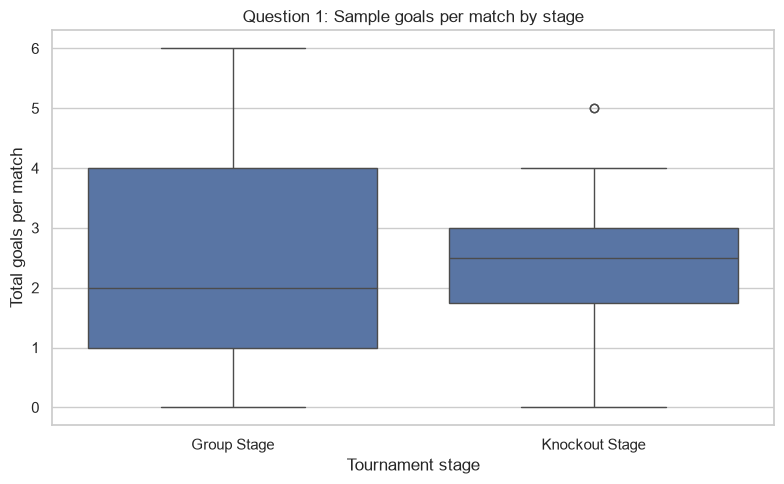

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=sample, x='Stage Group', y=variables[0], order=['Group Stage', 'Knockout Stage'])
plt.title('Question 1: Sample goals per match by stage')
plt.xlabel('Tournament stage')
plt.ylabel('Total goals per match')
plt.tight_layout()
plt.savefig(BASE / 'figures' / 'question1_boxplot.png', dpi=300)
plt.show()

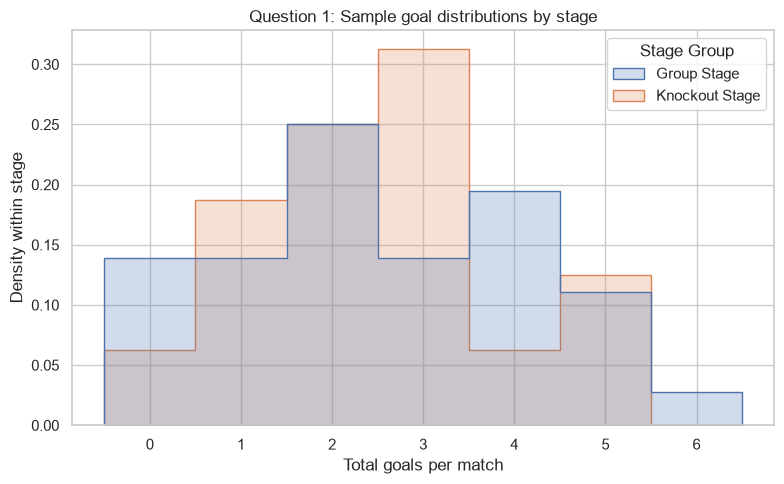

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data=sample, x=variables[0], hue='Stage Group', discrete=True, stat='density', common_norm=False, element='step')
plt.title('Question 1: Sample goal distributions by stage')
plt.xlabel('Total goals per match')
plt.ylabel('Density within stage')
plt.tight_layout()
plt.savefig(BASE / 'figures' / 'question1_histogram.png', dpi=300)
plt.show()

## 12. Save the final result
The analysis is visible above. The following small export block also preserves the summary and sample outputs for submission.

In [29]:
result_text = (
    f"Analytic question: {QUESTION}\nPopulation: {population_description}\n"
    f"Population size: {len(data)}\nSample size: {len(sample)}\n"
    "Sampling: half rounded up; without replacement; random_state=42; "
    "within stage for Q1, otherwise simple random matches.\n\n"
    + summary.to_string() + "\n\n" + ci_table.to_string(index=False)
    + f"\nH0: {h0}\nH1: {h1}\nAlpha: {alpha}\nt-statistic: {t_stat}\np-value: {p_value}"
    + f"\nDecision: {decision}\n{interpretation}\n"
)
(BASE / 'results' / f'question{NUMBER}_results.txt').write_text(result_text)
print(interpretation)
print('Saved sample, population, tables, figures and result text in:', BASE.name)

There is insufficient statistical evidence to conclude that the mean goals per match differs between Group and Knockout stages.
Saved sample, population, tables, figures and result text in: Question_1_Goals


## Interpretation limits
The supplied file contains 103 matches and omits the third-place match. Its authenticity and extra-time statistical coverage are not independently verified. Recorded match totals are retained even when they exceed half totals. The requested conventional t procedures use no finite-population correction despite sampling half the eligible data: these are approximate model-based intervals, not exact finite-population intervals. Repeated teams can weaken independence; small samples and skewness can affect accuracy. The four tests use nominal alpha 0.05 without multiplicity adjustment. Associations are not causal effects.